In [15]:
import numpy as np
import pandas as pd
import plot_style
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LinearRegression
plot_style.apply()

In [16]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 0.01 # std dev of the dividend process
sigma_x = 0.01 # std dev of the observable variable
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivity
constant_gain = 0.01  # constant gain parameter for learning
print(f"w: {w}, kappa: {kappa}")

w: 0.04272559525665953, kappa: 0.9581307815062262


## From here, the notebook does the following:

    - create simulated data for the observable x and returns r using our rolling window lasso and law of motion
    - use the simulated series for r in combination with x to estimate OLS coefficients
    - apply soft-thresholding to the series using same lambda and adjustment with s_xx
    - compare beta series --> they are the same

Before, beta estimates differed between Lasso and soft-thresholding because (1) scikit-learn uses a different objective function than we assume in our theory (1/2n instead of 1/2 in the LASSO loss function), which is now accounted for in the soft-thresholding function and (2) because the series for r generated under lasso was different than the series generated under ols, this is fixed now by using the alm generated return series from the lasso estimation in the ols estimation.

In [17]:
def multivariate_CGL_offline_lasso(T, K, sigma_x, sigma, kappa, w, rolling_window_size = 30, lambda_lasso = 0.01, correct_with_tanh = True):
    
    #assert that rolling_window_size < T otherwise offline estimation is not possible
    assert rolling_window_size < T, "rolling_window_size must be less than T"

    rng = np.random.default_rng(12345)
    x = rng.normal(0, sigma_x, size=(T, K)) # observable variables
    beta_offline = np.zeros((T, K, 1))
    r_offline = np.zeros(T)

    #Starting values
    r_offline[1:rolling_window_size+1] = rng.normal(0, 0.0001, rolling_window_size)



    for t in range(rolling_window_size+1, T):
        #generate x_current, up and including t-2
        x_current = x[t-rolling_window_size-1:t-1,:] #(x0, ... x299)
        r_offline_current = r_offline[t-rolling_window_size:t] # (r1, ... r300)
        beta_offline[t] = Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42).fit(x_current, r_offline_current).coef_.reshape(-1,1)
        if correct_with_tanh:
            r_offline[t] = (np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + rng.normal(0, sigma)).item()
        else:
            r_offline[t] = (np.log(1 - kappa * np.exp((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)))) - np.log(1 - kappa * np.exp((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)))) + rng.normal(0, sigma)).item() #r_301
    
    return beta_offline, r_offline, x

In [18]:
lambda_param = 0.00001
rolling_window_size= 300
beta_lasso, r_offline_lasso, x_lasso = multivariate_CGL_offline_lasso(T=10000, K=1, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, rolling_window_size=rolling_window_size, lambda_lasso=lambda_param, correct_with_tanh=False)

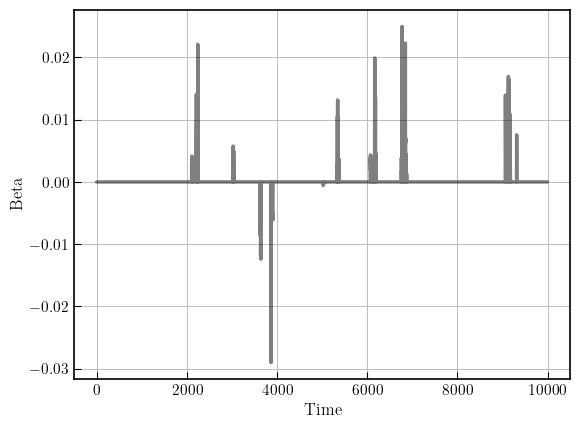

In [19]:
# visualize the lasso LASSO estimates
fig, ax = plt.subplots()
for k in range(beta_lasso.shape[1]):
    ax.plot(beta_lasso[:, k, 0], alpha = 0.5)
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
plt.show()

In [20]:
import numpy as np
from sklearn.linear_model import LinearRegression

def multivariate_CGL_offline_ols(r_offline, x, rolling_window_size=30):
    """
    Rolling-window OLS that *does not* generate returns.
    It takes an existing return series r_offline (length T) and regressors x (shape T×K),
    and estimates beta(t) on each window exactly as in your original indexing.

    Window at time t uses:
      x_current = x[t-window-1 : t-1]    # (x_{t-window-1}, ..., x_{t-2})
      y_current = r_offline[t-window : t]# (r_{t-window}, ..., r_{t-1})

    Returns
    -------
    beta_offline : (T, K, 1)
    r_offline    : (T,) (passed through)
    x            : (T, K) (passed through)
    s_xx         : (T, K, K) with NaN before first estimable t
    """
    r_offline = np.asarray(r_offline).reshape(-1)
    x = np.asarray(x)

    T = r_offline.shape[0]
    if x.ndim != 2:
        raise ValueError("x must be a 2D array of shape (T, K).")
    if x.shape[0] != T:
        raise ValueError(f"Shape mismatch: len(r_offline)={T} but x.shape[0]={x.shape[0]}.")
    K = x.shape[1]

    assert rolling_window_size < T, "rolling_window_size must be less than T"

    beta_offline = np.zeros((T, K, 1))
    s_xx = np.full((T, K, K), np.nan)

    for t in range(rolling_window_size + 1, T):
        x_current = x[t - rolling_window_size - 1 : t - 1, :]
        y_current = r_offline[t - rolling_window_size : t]

        # S_xx = mean over window of x x'
        s_xx[t] = (x_current.T @ x_current) / x_current.shape[0]

        beta_offline[t] = (
            LinearRegression(fit_intercept=False)
            .fit(x_current, y_current)
            .coef_
            .reshape(-1, 1)
        )

    return beta_offline, r_offline, x, s_xx


In [21]:
# given arrays r (T,) and x (T,K):
beta_ols, r_offline_ols, x_ols, s_xx = multivariate_CGL_offline_ols(r_offline=r_offline_lasso, x=x_lasso, rolling_window_size=300)

In [29]:
def lasso_from_beta_ols_path(beta_ols_path, s_xx_path, alpha, eps=1e-12, zero_tol=1e-8):
    """
    Soft-threshold OLS betas over time.
    """
    beta = np.asarray(beta_ols_path)
    s_xx = np.asarray(s_xx_path)

    # diagonal of S_xx(t)
    s_diag = np.diagonal(s_xx, axis1=1, axis2=2)

    # reshape for broadcasting
    s = s_diag[..., None]

    # lasso threshold
    thresh = alpha / s

    # soft-thresholding
    beta = np.sign(beta) * np.maximum(np.abs(beta) - thresh, 0.0)

    return beta, thresh, s_diag


In [38]:
print(np.nanmean(thresh))

0.099199345725539


In [30]:
# apply soft-thresholding to obtain lasso estimates
beta_soft, thresh, s_diag = lasso_from_beta_ols_path(beta_ols, s_xx, alpha=lambda_param)

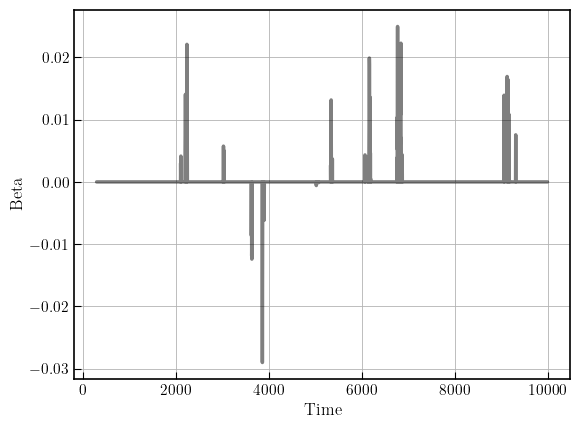

In [24]:
# visualize OLS estimates
fig, ax = plt.subplots()
for k in range(beta_soft.shape[1]):
    ax.plot(beta_soft[:, k, 0], alpha = 0.5)
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
plt.show()

In [25]:
## Diagnostics of differences between lasso and ols soft-thresholding

# construct data frame with columns beta_lasso, beta_ols, thresh, beta_softthres
T = beta_ols.shape[0]

data_lasso_ols = pd.DataFrame(index=range(T))
data_lasso_ols['beta_ols'] = beta_ols[:, 0, 0]
data_lasso_ols['beta_lasso'] = beta_lasso[:, 0, 0]
data_lasso_ols['beta_softthres'] = beta_soft[:, 0, 0]
data_lasso_ols['thresh'] = thresh[:, 0, 0]

# add column that subtracts abs(beta_ols) - thresh and is zero if negative
data_lasso_ols['abs_ols_minus_thresh'] = (
    data_lasso_ols['beta_ols'].abs() - data_lasso_ols['thresh']
).clip(lower=0.0)

# compute mean and median of the deviation
mean_deviation = data_lasso_ols['beta_lasso'] - data_lasso_ols['beta_softthres']
mean_deviation_value = mean_deviation.mean()
median_deviation_value = mean_deviation.median()
print(f"Mean deviation: {mean_deviation_value}, Median deviation: {median_deviation_value}")

# add one indicator that is 1 if beta_lass is nonzero
data_lasso_ols['indicator_beta_lasso_nonzero'] = (data_lasso_ols['beta_lasso'] != 0).astype(int)

# add one indicator that is 1 if abs(beta_ols) > thresh
data_lasso_ols['indicator_ols_above_thresh'] = (data_lasso_ols['beta_ols'].abs() > data_lasso_ols['thresh']).astype(int)

Mean deviation: 4.22048772244373e-19, Median deviation: 0.0


In [26]:
# print the sum of 1s in both indicators
sum_lasso_nonzero = data_lasso_ols['indicator_beta_lasso_nonzero'].sum()
sum_ols_above_thresh = data_lasso_ols['indicator_ols_above_thresh'].sum()
print(f"Sum of beta_lasso nonzero: {sum_lasso_nonzero}, Sum of ols above thresh: {sum_ols_above_thresh}")

Sum of beta_lasso nonzero: 268, Sum of ols above thresh: 268


In [27]:
# create a dataset with x and r
# generate fictituous dates  
dates = pd.date_range(start='2000-01-01', periods=10000, freq='D')
data = pd.DataFrame(data=x_lasso, index=dates, columns=[f'x_{i+1}' for i in range(x_lasso.shape[1])])
data['r'] = r_offline_lasso

#loop to save the betas
for i in range(beta_lasso.shape[1]):
    data[f'beta_{i+1}'] = beta_lasso[:, i, 0]

data.to_csv('simulation_data_lasso.csv')

In [39]:
#create a dataset with x and r
#generate fictituous dates beta_ols, r_offline, x, s_xx
import pandas as pd
dates = pd.date_range(start='2000-01-01', periods=10000, freq='D')
data = pd.DataFrame(data=x_ols, index=dates, columns=[f'x_{i+1}' for i in range(x_ols.shape[1])])
data['r'] = r_offline_ols

#loop to save the betas
for i in range(beta_soft.shape[1]):
    data[f'beta_soft{i+1}'] = beta_soft[:, i, 0]

#loop to save original ols estimates
for i in range(beta_ols.shape[1]):
    data[f'beta_ols{i+1}'] = beta_ols[:, i, 0]

# replcae nans with zeros
data = data.fillna(0)

data.to_csv('simulation_data_ols_soft.csv')